# Genetic Algorithm (GA) Implementation

Genetic Algorithm (GA) is a population-based optimization algorithm inspired by natural selection.

Instead of improving a single state step by step, GA works with a **population** of candidate solutions and repeatedly applies:

1. **Selection** - choose better individuals
2. **Crossover** - combine parents to create children
3. **Mutation** - slightly change individuals
4. **Replacement** - form the next generation

### Objective Function

We want to maximize:

$$
f(x) = x \cdot \sin(x)
$$

within the interval:

$$
0 \le x \le 10
$$

### Why Genetic Algorithm?

Unlike Hill Climbing, which can get stuck in local optima, and unlike Simulated Annealing, which explores with a single moving solution, Genetic Algorithm explores the search space using many candidate solutions at the same time.


In [1]:
import math
import random


### Step 2: Define the Objective Function and Basic Helpers

Each individual in the population is represented by a single real number $x$ in the interval $[0, 10]$.


In [2]:
def objective_function(x):
    return x * math.sin(x)


def random_individual(bounds):
    return random.uniform(bounds[0], bounds[1])


def fitness(x):
    return objective_function(x)


### Step 3: Selection, Crossover, and Mutation

We use:

- **Tournament Selection** to choose stronger parents
- **Arithmetic Crossover** to combine two parents
- **Gaussian Mutation** to introduce random variation


In [3]:
def tournament_selection(population, k=3):
    candidates = random.sample(population, k)
    return max(candidates, key=fitness)


def crossover(parent1, parent2):
    alpha = random.random()
    child = alpha * parent1 + (1 - alpha) * parent2
    return child


def mutation(x, bounds, mutation_strength=0.3, mutation_rate=0.2):
    if random.random() < mutation_rate:
        x += random.gauss(0, mutation_strength)

    # Keep x inside bounds
    x = max(bounds[0], min(bounds[1], x))
    return x


### Step 4: Genetic Algorithm Implementation

The algorithm starts with a random population, evaluates individuals, and generates new generations until the maximum number of generations is reached.


In [4]:
def genetic_algorithm(
    bounds,
    population_size=20,
    generations=40,
    crossover_rate=0.9,
    mutation_rate=0.2,
    mutation_strength=0.3,
    elitism=True,
):
    # Initial random population
    population = [random_individual(bounds) for _ in range(population_size)]

    best_overall = max(population, key=fitness)
    best_overall_fitness = fitness(best_overall)

    print("Starting Genetic Algorithm\n")

    for generation in range(1, generations + 1):
        # Sort population by fitness descending
        population = sorted(population, key=fitness, reverse=True)

        current_best = population[0]
        current_best_fitness = fitness(current_best)

        if current_best_fitness > best_overall_fitness:
            best_overall = current_best
            best_overall_fitness = current_best_fitness

        print(
            f"Generation {generation:02d} | "
            f"Best x = {current_best:.4f} | "
            f"Best f(x) = {current_best_fitness:.4f}"
        )

        new_population = []

        # Keep the best individual if elitism is enabled
        if elitism:
            new_population.append(population[0])

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, k=3)
            parent2 = tournament_selection(population, k=3)

            if random.random() < crossover_rate:
                child = crossover(parent1, parent2)
            else:
                child = parent1

            child = mutation(
                child,
                bounds,
                mutation_strength=mutation_strength,
                mutation_rate=mutation_rate,
            )

            new_population.append(child)

        population = new_population

    return best_overall, best_overall_fitness


### Step 5: Run the Genetic Algorithm

We now run GA to search for the global maximum of the function in the range $[0, 10]$.


In [5]:
bounds = (0.0, 10.0)
random.seed(42)

best_x, best_val = genetic_algorithm(
    bounds,
    population_size=20,
    generations=40,
    crossover_rate=0.9,
    mutation_rate=0.25,
    mutation_strength=0.4,
    elitism=True,
)

print("\n" + "-" * 45)
print(f"Best Solution Found: x = {best_x:.4f}")
print(f"Best Value Found: f(x) = {best_val:.4f}")


Starting Genetic Algorithm

Generation 01 | Best x = 8.0943 | Best f(x) = 7.8617
Generation 02 | Best x = 7.9738 | Best f(x) = 7.9166
Generation 03 | Best x = 7.9738 | Best f(x) = 7.9166
Generation 04 | Best x = 7.9738 | Best f(x) = 7.9166
Generation 05 | Best x = 7.9793 | Best f(x) = 7.9167
Generation 06 | Best x = 7.9793 | Best f(x) = 7.9167
Generation 07 | Best x = 7.9792 | Best f(x) = 7.9167
Generation 08 | Best x = 7.9784 | Best f(x) = 7.9167
Generation 09 | Best x = 7.9786 | Best f(x) = 7.9167
Generation 10 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 11 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 12 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 13 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 14 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 15 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 16 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 17 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 18 | Best x = 7.9787 | Best f(x) = 7.9167
Generation 19 | Be

### Step 6: Expected Behavior

Because GA is stochastic, the exact output may differ slightly from one run to another.

However, with the fixed random seed, the algorithm should move toward the region near:

$$
x \approx 7.98
$$

where the function reaches its global maximum:

$$
f(x) \approx 7.92
$$


In [6]:
# Optional: compare with the true best region by sampling
best_sample_x = None
best_sample_val = float("-inf")

x = 0.0
step = 0.001

while x <= 10.0:
    val = objective_function(x)
    if val > best_sample_val:
        best_sample_val = val
        best_sample_x = x
    x += step

print(f"Approximate true optimum by sampling: x = {best_sample_x:.3f}")
print(f"Approximate true maximum value: f(x) = {best_sample_val:.4f}")


Approximate true optimum by sampling: x = 7.979
Approximate true maximum value: f(x) = 7.9167


Optimal Solution Found: x = 7.9787 | f(x) = 7.9167


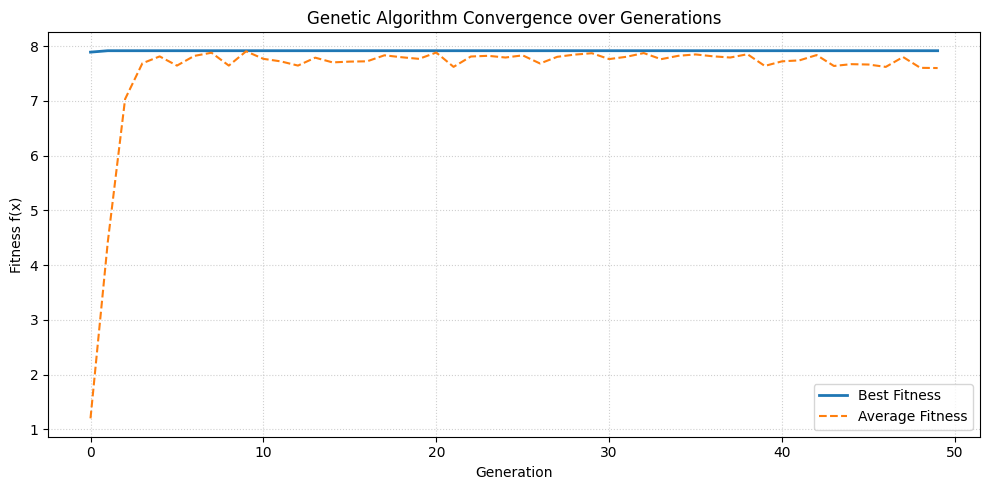

In [7]:
import math
import random
import matplotlib.pyplot as plt


# 1. Objective function and helpers
def objective_function(x):
    return x * math.sin(x)


def fitness(x):
    return objective_function(x)


def random_individual(bounds):
    return random.uniform(bounds[0], bounds[1])


def tournament_selection(population, k=3):
    candidates = random.sample(population, k)
    return max(candidates, key=fitness)


def crossover(parent1, parent2):
    alpha = random.random()
    return alpha * parent1 + (1 - alpha) * parent2


def mutation(x, bounds, mutation_strength=0.4, mutation_rate=0.25):
    if random.random() < mutation_rate:
        x += random.gauss(0, mutation_strength)
    return max(bounds[0], min(bounds[1], x))


# 2. GA Implementation with History Tracking
def genetic_algorithm_with_plot(
    bounds,
    population_size=30,
    generations=50,
    crossover_rate=0.9,
    mutation_rate=0.25,
    mutation_strength=0.4,
    elitism=True,
):
    population = [random_individual(bounds) for _ in range(population_size)]

    history_best = []
    history_avg = []

    best_overall = max(population, key=fitness)
    best_overall_fitness = fitness(best_overall)

    for gen in range(1, generations + 1):
        population = sorted(population, key=fitness, reverse=True)

        current_best = population[0]
        current_best_fitness = fitness(current_best)
        current_avg_fitness = sum(fitness(ind) for ind in population) / len(
            population
        )

        history_best.append(current_best_fitness)
        history_avg.append(current_avg_fitness)

        if current_best_fitness > best_overall_fitness:
            best_overall = current_best
            best_overall_fitness = current_best_fitness

        # Elitism
        new_population = []
        if elitism:
            new_population.append(population[0])

        # Reproduce
        while len(new_population) < population_size:
            p1 = tournament_selection(population, k=3)
            p2 = tournament_selection(population, k=3)

            child = (
                crossover(p1, p2) if random.random() < crossover_rate else p1
            )
            child = mutation(
                child,
                bounds,
                mutation_strength=mutation_strength,
                mutation_rate=mutation_rate,
            )
            new_population.append(child)

        population = new_population

    return best_overall, best_overall_fitness, history_best, history_avg


# 3. Run and Plot Results
bounds = (0.0, 10.0)
random.seed(42)

best_x, best_val, history_best, history_avg = genetic_algorithm_with_plot(
    bounds,
    population_size=30,
    generations=50,
    crossover_rate=0.9,
    mutation_rate=0.25,
    mutation_strength=0.4,
    elitism=True,
)

print(f"Optimal Solution Found: x = {best_x:.4f} | f(x) = {best_val:.4f}")

# Plotting Generation Progress
plt.figure(figsize=(10, 5))
plt.plot(history_best, label="Best Fitness", color="#1f77b4", linewidth=2)
plt.plot(
    history_avg,
    label="Average Fitness",
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.5,
)
plt.title("Genetic Algorithm Convergence over Generations", fontsize=12)
plt.xlabel("Generation", fontsize=10)
plt.ylabel("Fitness f(x)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
